# Import + GPU Setup + Mixed Precision

In [12]:
# ============================================================
# PART 1 — IMPORT & GPU SETUP
# ============================================================
!pip install Optuna
!pip install transformers
import tensorflow as tf
from tensorflow.keras import mixed_precision
import numpy as np
import pandas as pd
import gc

from transformers import TFDistilBertModel, DistilBertTokenizerFast
from tensorflow.keras.layers import Input, Bidirectional, GRU, GlobalAveragePooling1D, Dropout, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

import optuna

# Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Memory growth enabled on GPU")
    except:
        pass


Memory growth enabled on GPU


# Global Parameters

In [13]:
MAX_LEN = 64       # Dikurangi dari 128 → hemat memori
BATCH_SIZE = 8     # Dikurangi dari 16 → aman untuk T4
EPOCHS = 1         # Sementara untuk Optuna testing



# Load Dataset

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
file_path = "/content/drive/MyDrive/DistilBERT-7-Mei/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load Tokenizer + Tokenize Function

In [16]:
# ============================================================
# PART 4 — TOKENIZER
# ============================================================

tokenizer = DistilBertTokenizerFast.from_pretrained("cahya/distilbert-base-indonesian")

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="tf"
    )


# Tokenisasi data Split Train/Test/Val

In [17]:
train_inputs = tokenize(X_train)
val_inputs   = tokenize(X_val)
test_inputs  = tokenize(X_test)

# Load Model Distilbert Indonesia Lang

In [18]:
# ============================================================
# PART 6 — LOAD BERT MODEL ONCE (IMPORTANT)
# ============================================================

bert_model = TFDistilBertModel.from_pretrained("cahya/distilbert-base-indonesian", from_pt=True)
bert_model.trainable = False   # freeze → hemat memory

# Explicitly build the bert_model to define its input shape for Keras functional API
# (None, MAX_LEN) for input_ids and (None, MAX_LEN) for attention_mask
bert_model.build(input_shape=[(None, MAX_LEN), (None, MAX_LEN)])

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.weight', 'vocab_transform.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


# Build Model Function

In [19]:
# ============================================================
# PART 7 — BUILD MODEL FUNCTION
# ============================================================

# Define a wrapper for the frozen bert_model
class BertWrapper(tf.keras.layers.Layer):
    def __init__(self, bert_model_instance, **kwargs):
        super().__init__(**kwargs)
        # Register the bert_model_instance as a sub-layer explicitly
        self.bert_model = bert_model_instance

    def call(self, inputs):
        input_ids, attention_mask = inputs
        # The transformers model expects keyword arguments
        return self.bert_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)[0]

def build_model(gru_units, dropout_rate, lr):

    input_ids = Input(shape=(MAX_LEN,), dtype=tf.int32, name="input_ids")
    att_mask  = Input(shape=(MAX_LEN,), dtype=tf.int32, name="attention_mask")

    # Instantiate the wrapper with the global bert_model
    bert_wrapper = BertWrapper(bert_model, name="bert_wrapper_layer")
    hidden_states = bert_wrapper([input_ids, att_mask]) # Pass inputs as a list/tuple

    x = Bidirectional(GRU(gru_units, return_sequences=True))(hidden_states)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid", dtype="float32")(x)

    model = Model(inputs=[input_ids, att_mask], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Training Final Model

In [20]:
# ============================================================
# PART 10 — TRAIN FINAL MODEL
# ============================================================

# BASELINE Params: {'h_units': 64, 'dropout': 0.3, 'lr': 0.001}


final_model = build_model(
    gru_units = 64,
    dropout_rate = 0.3,
    lr = 0.001
)

final_model.fit(
    dict(train_inputs),
    y_train,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(dict(val_inputs), y_val.values) # Pass validation data explicitly as a dictionary
)

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 34s 102ms/step - accuracy: 0.7100 - loss: 0.5532 - val_accuracy: 0.8357 - val_loss: 0.3851
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.8510 - loss: 0.3253 - val_accuracy: 0.8357 - val_loss: 0.3830
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8984 - loss: 0.2468 - val_accuracy: 0.8792 - val_loss: 0.3271
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9375 - loss: 0.1669 - val_accuracy: 0.8696 - val_loss: 0.2932
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.9455 - loss: 0.1381 - val_accuracy: 0.8696 - val_loss: 0.3982
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.9745 - loss: 0.0842 - val_accuracy: 0.8744 - val_loss: 0.4143
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9910 - loss: 0.0374 - val_accuracy: 0.8841 - val_loss: 0.4249
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.9959 - loss: 0.0218 - val_

# Evaluation on Test Set

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step
              precision    recall  f1-score   support

         0.0     0.8884    0.9079    0.8980       228
         1.0     0.8840    0.8602    0.8719       186

    accuracy                         0.8865       414
   macro avg     0.8862    0.8841    0.8850       414
weighted avg     0.8864    0.8865    0.8863       414



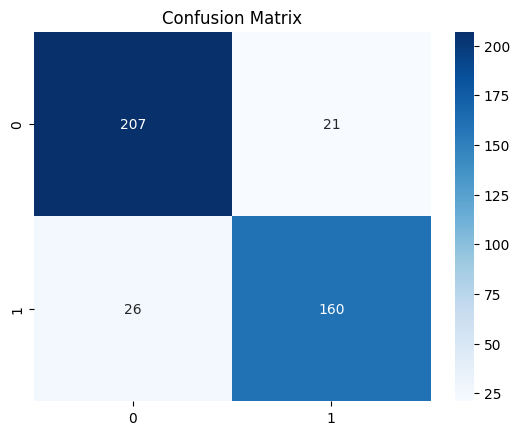

Macro F1: 0.8849911636236827


In [21]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (final_model.predict(dict(test_inputs)) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

In [22]:
# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(y_test)) # Use len(y_test) for size
subset = {'input_ids': test_inputs['input_ids'][:benchmark_size], 'attention_mask': test_inputs['attention_mask'][:benchmark_size]} # Correctly slice the dictionary of tensors

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")


🕒 Avg batch inference time: 0.1177306318283081
📊 Throughput: 271.80691637387156 samples/sec
